In [48]:
datafolder = 'data/'
recdata = 'recdata/'
recdata_folder = datafolder+recdata
data_type_suffix = '.dat'

tmpfolder = 'tmp/'
from sympy import init_printing
init_printing()

%matplotlib inline
import sympybotics

In [49]:
datasets = [
    # 'rbtlog_4_dof',
    # 'rbtlog_16',
    'ares/rbtlog_1',
    'ares/rbtlog_2',
    'ares/rbtlog_5',
    # 'slax/rbtlog_2_4_dof',
    # 'slax/rbtlog_3_4_dof',
    # 'slax/rbtlog_9_4_dof',
    # 'slax/rbtlog_10_4_dof',
    # 'slax/rbtlog_11_4_dof',
    # 'zeus/rbtlog_9_4_dof',
    # 'zeus/rbtlog_15_4_dof',
]
    

In [50]:
import pandas as pd

residual_dataset = []

for d in datasets:
    dataset_path = recdata_folder + d + data_type_suffix

    df = pd.read_csv(dataset_path, sep=r'\s+')
    print(df.shape)
    print(len(df.columns))
    df.head()
        

(14998, 9)
9
(14999, 9)
9
(15000, 9)
9


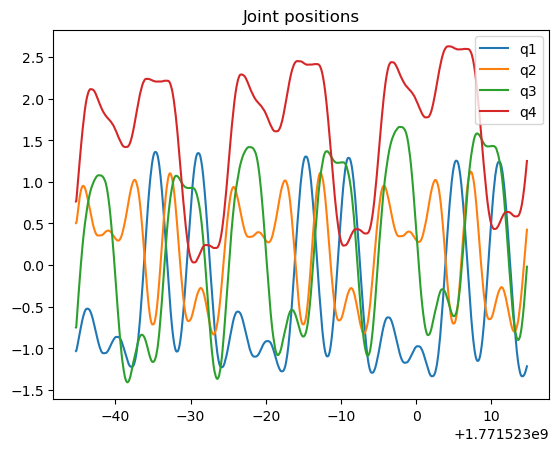

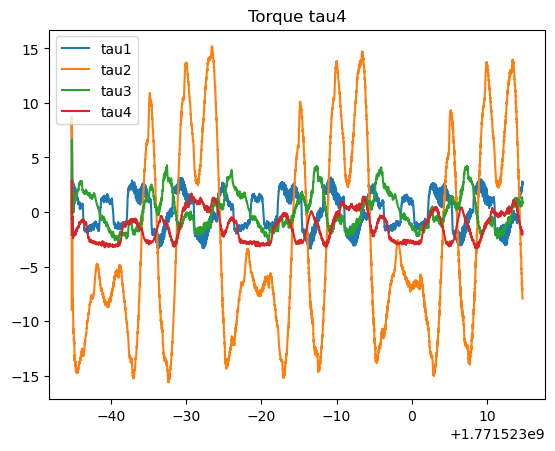

CPU times: user 1.35 s, sys: 3.82 ms, total: 1.36 s
Wall time: 1.36 s
CPU times: user 917 ms, sys: 20.2 ms, total: 937 ms
Wall time: 796 ms
{'S': 500.0, 'h': 0.04, 'wf': 0.3141592653589793, 'L': 5.0}


(10827, 4)
 (cond=36.559032)


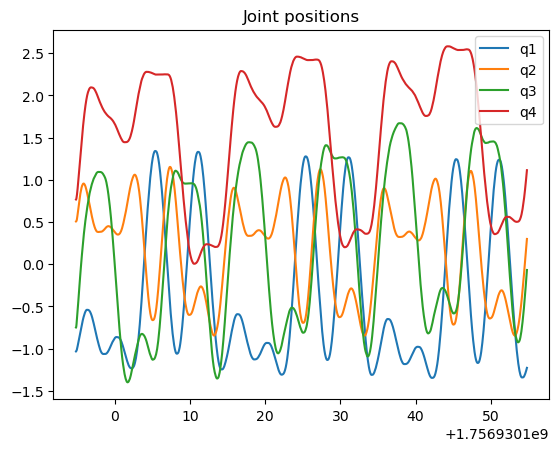

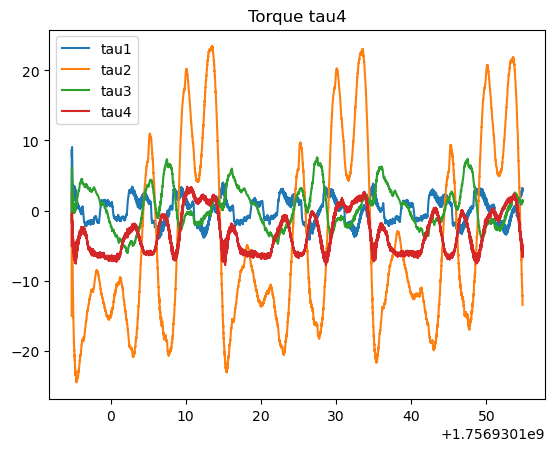

CPU times: user 1.34 s, sys: 0 ns, total: 1.34 s
Wall time: 1.34 s
CPU times: user 869 ms, sys: 25.2 ms, total: 894 ms
Wall time: 782 ms
{'S': 500.0, 'h': 0.04, 'wf': 0.3141592653589793, 'L': 5.0}


(10828, 4)
 (cond=37.213840)


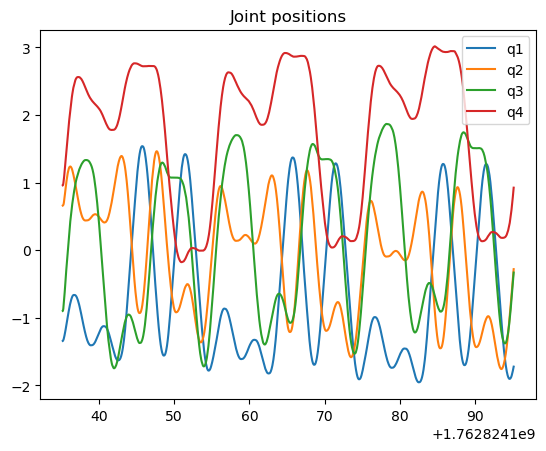

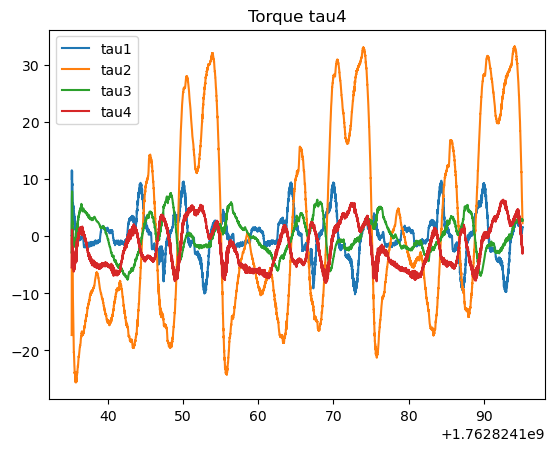

CPU times: user 1.35 s, sys: 817 µs, total: 1.35 s
Wall time: 1.35 s
CPU times: user 929 ms, sys: 16.9 ms, total: 946 ms
Wall time: 803 ms
{'S': 500.0, 'h': 0.04, 'wf': 0.3141592653589793, 'L': 5.0}


(10829, 4)
 (cond=24.667962)


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

import math
import numpy
from math import pi

# Register them in global scope for exec() to see
import builtins
builtins.math = math
builtins.numpy = numpy
builtins.pi = pi

import numpy as np
from sympy import iterables

import pickle

residual_dataset = []
q_dataset = []
dq_dataset = [] 
ddq_dataset = []

with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')


for d in datasets:
    dataset_path = recdata_folder + d + data_type_suffix

    df = pd.read_csv(dataset_path, sep=r'\s+')

    if len(df.columns) == 9: # make sure data complies with 4 dof
        
        plt.figure()
        df.columns = [
            "t",
            "q1", "q2", "q3", "q4",
            "tau1", "tau2", "tau3", "tau4"
        ]
        for col in ["q1", "q2", "q3", "q4"]:
            plt.plot(df["t"], df[col], label=col)
        plt.legend()
        plt.title("Joint positions")
        plt.show()
        
        plt.figure()
        for col in ["tau1", "tau2", "tau3", "tau4"]:
            plt.plot(df["t"], df[col], label=col)
            plt.legend()
            plt.title(f"Torque {col}")
        
        plt.show()

        rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
            [("-pi/2", 0, 0, "q"),
             ("pi/2", 0, 0, "q"),
             ("-pi/2", 0.045, 0.55, "q"),
             ("pi/2", -0.045, 0, "q")],
            dh_convention="standard")

        %time rbt = sympybotics.RobotDynCode(rbtdef)
        %time rbt.calc_base_parms()


        with open(tmpfolder + 'robotmodels/wam4_model.pkl', 'wb') as file:
            pickle.dump( rbt, file )
        
        with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
                  rbt = pickle.load( file )
        
        rbt.dyn.n_dynparms, rbt.dyn.n_base
        
        rbt.dyn.dynparms.n()
        rbt.dyn.baseparms.n()

        # Step 1: Convert symbolic matrix to NumPy array
        Pb_matrix = np.array(rbt.dyn.Pb.tolist(), dtype=np.float64)  # already 0/1
        Pb_flat = Pb_matrix.flatten()
        
        # Step 2: Generate C++ code
        cpp_array_str = 'double Pb[1440] = {\n'
        for i, val in enumerate(Pb_flat):
            cpp_array_str += f'{int(val)}, '  # write as integer 0 or 1
            if (i + 1) % 12 == 0:  # break line every 12 entries
                cpp_array_str += '\n'
        cpp_array_str += '};'
        
        with open('Pb_array.cpp', 'w') as f:
            f.write(cpp_array_str)

        # h = 0.004
        # decimate = 1
        # h_plot = h*decimate # downsample it so that it has the frequency of 500 (originally it has been 1000)
        
        # with open(datafolder +  'trajectories/traj_4.dat', 'r' ) as file:
        #           q_ref_orig = numpy.loadtxt(file)
        # print(q_ref_orig.shape)
        # q_ref = q_ref_orig
        # with open(dataset_path, 'r' ) as file:
        #           q_raw_orig = numpy.loadtxt(file)
        # print(q_raw_orig.shape)
        # s = q_ref_orig.shape[0] // decimate
        
        # q_ref = numpy.zeros((s, rbt.dof))
        # for i in range(s):
        #     q_ref[i, :] = q_ref_orig[i*decimate, :]
        # print(q_ref.shape)

        # si = 0
        # sf = si + 60/h_plot
        # t = numpy.arange(sf-si) * h_plot

        with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
            s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')
        
        print(dict(zip(('S', 'h', 'wf', 'L'), s_h_wf_l)))
        print('\n')
        
        fc_mult = 10
        
        wf = float(s_h_wf_l[2])
        L = float(s_h_wf_l[3])
        fc = fc_mult * ( wf / (2*math.pi) * L )
        fc
        
        fc_q = fc
        fc_dq = fc
        fc_ddq = fc
        
        fc_tau = fc
        
        si = int(3/0.001)
        sf = -int(1/0.001)-172

        rec_h = 0.004 # sampling time

        from support_funcs.regr_data_proc import read_data, diff_and_filt_data, gen_regr_matrices
        from support_funcs.utils import _fprint
        
        t_raw, q_raw, tau_raw, t_ref, q_ref = read_data(dof=rbt.dof, h=rec_h,
                                                        rbtlogfile=dataset_path,
                                                        trajreffile=datafolder + 'trajectories/traj_4.dat')
        
        q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
                                       fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)
        
        t_raw = t_raw[si:sf]; q_raw = q_raw[si:sf]; tau_raw = tau_raw[si:sf]
        q = q[si:sf]; dq = dq[si:sf]; ddq = ddq[si:sf]; tau = tau[si:sf]
        
        t_raw = t_raw - t_raw[0]
        
        t = numpy.array(range(q.shape[0])) * rec_h
        print(np.shape(q))
        H_S, W, omega, Q1, R1, rho1 = gen_regr_matrices(rbt, q, dq, ddq, tau)
        
        _fprint(' (cond=%f)'%numpy.linalg.cond(W))

        tau_vec= tau.reshape(W.shape[0], -1)

        beta, *_ = np.linalg.lstsq(W, tau_vec, rcond=None)
        tau_rbd = W @ beta #friction from the reduced H_S == W regressor model

        tau_rbd = tau_rbd.reshape(-1,1)
        tau_vec= tau_vec.reshape(-1,1)
        tau_residual = tau_vec - tau_rbd
        tau_residual = tau_residual.reshape(-1, rbt.dof)

        residual_dataset.append(tau_residual)
        q_dataset.append(q)
        dq_dataset.append(dq)
        ddq_dataset.append(ddq)
                                                
        # GOAL: get residual and combine into one bigger dataset
        

In [52]:
for i in range(len(residual_dataset)):
    print(residual_dataset[i].shape)
    print(q_dataset[i].shape)

print("###")
joints = []
for i in range(rbt.dof):
    print(f"dof: {i}")
    residual_tau_i = []
    q_i = []
    dq_i = []
    ddq_i = []
    for j in range(len(residual_dataset)):
        print(f"j: {j}")
        print(residual_dataset[j].shape)
        print(q_dataset[j].shape)
        print(dq_dataset[j].shape)
        print(ddq_dataset[j].shape)
        residual_tau_i.append(residual_dataset[j][:,i])
        
        q_i.append(q_dataset[j][:,i])
        dq_i.append(dq_dataset[j][:,i])
        ddq_i.append(ddq_dataset[j][:,i])

    residual_tau_i = np.concatenate([np.asarray(x).reshape(-1) for x in residual_tau_i])
    q_i            = np.concatenate([np.asarray(x).reshape(-1) for x in q_i])
    dq_i           = np.concatenate([np.asarray(x).reshape(-1) for x in dq_i])
    ddq_i          = np.concatenate([np.asarray(x).reshape(-1) for x in ddq_i])
    df = pd.DataFrame({
    "q": q_i,
    "dq": dq_i,
    "ddq": ddq_i,
    "tau_residual": residual_tau_i
    })
    joints.append(df)


# for each joint have dataset be [res1 res2 ... resn ; q1 q2 ... qn ] so that the split from each dataset is not really apparent
joints


(10827, 4)
(10827, 4)
(10828, 4)
(10828, 4)
(10829, 4)
(10829, 4)
###
dof: 0
j: 0
(10827, 4)
(10827, 4)
(10827, 4)
(10827, 4)
j: 1
(10828, 4)
(10828, 4)
(10828, 4)
(10828, 4)
j: 2
(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)
dof: 1
j: 0
(10827, 4)
(10827, 4)
(10827, 4)
(10827, 4)
j: 1
(10828, 4)
(10828, 4)
(10828, 4)
(10828, 4)
j: 2
(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)
dof: 2
j: 0
(10827, 4)
(10827, 4)
(10827, 4)
(10827, 4)
j: 1
(10828, 4)
(10828, 4)
(10828, 4)
(10828, 4)
j: 2
(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)
dof: 3
j: 0
(10827, 4)
(10827, 4)
(10827, 4)
(10827, 4)
j: 1
(10828, 4)
(10828, 4)
(10828, 4)
(10828, 4)
j: 2
(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)


[              q        dq       ddq  tau_residual
 0      0.192209 -1.329448 -0.094070     -2.604439
 1      0.186891 -1.329741 -0.051480     -2.610504
 2      0.181572 -1.329851 -0.002767     -2.623266
 3      0.176252 -1.329760  0.048600     -2.641678
 4      0.170934 -1.329464  0.098897     -2.664290
 ...         ...       ...       ...           ...
 32479  0.296884  1.482827 -0.062853      5.014321
 32480  0.302815  1.482486 -0.107230      5.020219
 32481  0.308744  1.481975 -0.147001      5.022944
 32482  0.314671  1.481319 -0.179708      5.017615
 32483  0.320594  1.480550 -0.202892      4.998736
 
 [32484 rows x 4 columns],
               q        dq       ddq  tau_residual
 0      0.878326  0.815276 -1.516601      1.914452
 1      0.881575  0.809163 -1.539776      1.914768
 2      0.884799  0.802961 -1.560586      1.917749
 3      0.887999  0.796681 -1.578937      1.923170
 4      0.891173  0.790333 -1.594739      1.930656
 ...         ...       ...       ...           ...
 3

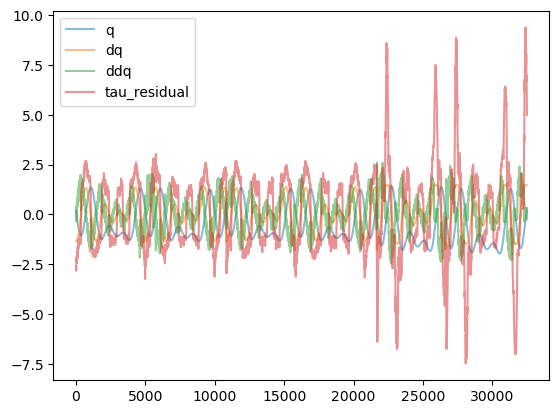

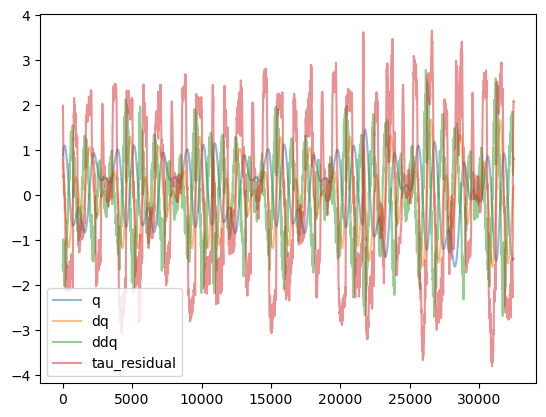

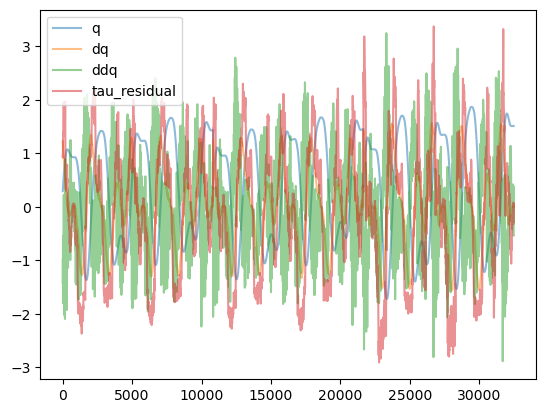

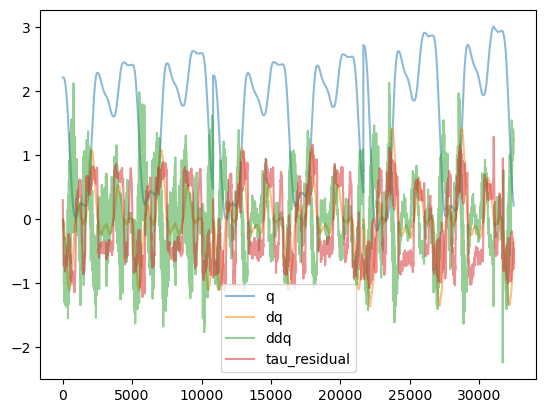

In [53]:
for i in range(len(joints)):
    joints[i].plot(alpha=0.5)

In [54]:
ls


 create_residual_dataset.ipynb
 create_trajectory.py
 data/
 debug_plot.png
 Feas-Ident-WAM4/
 friction_modeling.ipynb
 friction_modeling_requirements.txt
'Paper IROS2013 - Phys Feas Dyn Param Ident 4-DOF WAM Rob.ipynb'
'Paper IROS2013 - Phys Feas Dyn Param Ident 7-DOF WAM Rob.html'
 Pb_array.cpp
 process_data.py
 README.md
 regressor_func.cpp
 regressor_func.py
 residual_data/
 support_funcs/
 symindy/
 test_sym_regressor.py
 test_trajectory.py
 tmp/


In [55]:
for i in range(len(joints)):
    joints[i].to_csv(f'residual_data/ares_combined_datasets__joint_{i}')

In [56]:
ls


 create_residual_dataset.ipynb
 create_trajectory.py
 data/
 debug_plot.png
 Feas-Ident-WAM4/
 friction_modeling.ipynb
 friction_modeling_requirements.txt
'Paper IROS2013 - Phys Feas Dyn Param Ident 4-DOF WAM Rob.ipynb'
'Paper IROS2013 - Phys Feas Dyn Param Ident 7-DOF WAM Rob.html'
 Pb_array.cpp
 process_data.py
 README.md
 regressor_func.cpp
 regressor_func.py
 residual_data/
 support_funcs/
 symindy/
 test_sym_regressor.py
 test_trajectory.py
 tmp/


In [57]:
ls ../

create_residual_dataset.ipynb  IROS2013-Feas-Ident-WAM7/  SymPyBotics/
environment.yml                PyLMI-SDP/                 Untitled.ipynb
Feas-Ident-WAM4/               README.md
